In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup, AutoTokenizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Split Data

In [ ]:
# 1. Persiapan Data (Simulasi)
# Ganti bagian ini dengan pd.read_csv("nama_file_anda.csv") jika data sudah siap
data = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/dataset/Komentar_Youtube_bersih_berlabel_3.csv")
df = pd.DataFrame(data)

# Pisahkan fitur (X) dan target/label (y)
X = df['Teks']
y = df['Label']

# 2. Langkah Pertama: Pisahkan Data Uji (Test)
# Kita ambil 15% untuk Test, sisanya 85% akan menjadi data latih sementara (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # Menjaga proporsi kelas (Positif/Negatif) tetap seimbang
)

# 3. Langkah Kedua: Pisahkan sisa data (X_temp) menjadi Train dan Validation
# Kita ingin Validation menjadi 15% dari TOTAL data awal.
# Karena X_temp adalah 85% dari total, maka persentase pembagiannya adalah: 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=(0.15 / 0.85),
    random_state=42,
    stratify=y_temp
)

# 4. (Opsional) Gabungkan kembali menjadi DataFrame agar rapi
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
val_df = pd.DataFrame({'text': X_val, 'label': y_val})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

# 5. Tampilkan Hasil Pembagian
print("=== HASIL PEMBAGIAN DATA ===")
print(f"Total Data Awal: {len(df)}")
print(f"Data Latih (Train)  : {len(train_df)} data ({(len(train_df)/len(df))*100:.0f}%)")
print(f"Data Validasi (Val) : {len(val_df)} data ({(len(val_df)/len(df))*100:.0f}%)")
print(f"Data Uji (Test)     : {len(test_df)} data ({(len(test_df)/len(df))*100:.0f}%)")

=== HASIL PEMBAGIAN DATA ===
Total Data Awal: 10990
Data Latih (Train)  : 7692 data (70%)
Data Validasi (Val) : 1649 data (15%)
Data Uji (Test)     : 1649 data (15%)


# Tokenizing

In [ ]:
# 1. Definisikan path model dari Hugging Face yang kamu gunakan
# (Sesuaikan path ini jika kamu menggunakan versi spesifik lainnya)
model_paths = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "IndoRoBERTa": "cahya/roberta-base-indonesian-522M",
    "IndoELECTRA": "mesolitica/electra-base-discriminator-bahasa-cased"
}

# 2. Inisialisasi dictionary untuk menyimpan ketiga tokenizer
tokenizers = {}
for model_name, path in model_paths.items():
    print(f"Mengunduh tokenizer untuk {model_name}...")
    tokenizers[model_name] = AutoTokenizer.from_pretrained(path)

# 3. Fungsi Tokenisasi
def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding='max_length', # Menyamakan panjang kalimat (menambah angka 0 jika kalimat pendek)
        truncation=True,      # Memotong kalimat jika melebihi max_length
        max_length=max_length,
        return_tensors='pt'   # 'pt' untuk PyTorch, ubah jadi 'tf' jika pakai TensorFlow
    )

Mengunduh tokenizer untuk IndoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Mengunduh tokenizer untuk IndoELECTRA...


config.json:   0%|          | 0.00/810 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# ==========================================
# Tokenizing
# ==========================================

# 4. Lakukan tokenisasi untuk Masing-masing Model dan Masing-masing Split
print("\nMelakukan Tokenisasi untuk Train, Val, dan Test...")
tokenized_inputs = {}

for model_name, tokenizer in tokenizers.items():
    print(f"-> Memproses {model_name}...")
    tokenized_inputs[model_name] = {
        # Ganti 'text' dengan nama kolom Anda
        'train': tokenize_data(train_df['text'], tokenizer),
        'val': tokenize_data(val_df['text'], tokenizer),
        'test': tokenize_data(test_df['text'], tokenizer)
    }

print("Selesai! Data siap digunakan untuk PyTorch/TensorFlow.")

# Contoh cara memanggil hasilnya:
# input_ids_train_indobert = tokenized_inputs["IndoBERT"]['train']['input_ids']


Melakukan Tokenisasi untuk Train, Val, dan Test...
-> Memproses IndoBERT...
-> Memproses IndoRoBERTa...
-> Memproses IndoELECTRA...
Selesai! Data siap digunakan untuk PyTorch/TensorFlow.


In [ ]:
print("Kolom yang tersedia di dalam data tokenized (contoh IndoBERT, train split):")
# Ambil salah satu model dan split untuk contoh
example_tokenized_data = tokenized_inputs["IndoBERT"]['train']

# Cetak kunci-kunci (kolom) yang ada
for key in example_tokenized_data.keys():
    print(f"- {key}")

# Jika ingin melihat bentuk datanya, contoh:
print("\nBentuk data 'input_ids' untuk IndoBERT (train):")
print(example_tokenized_data['input_ids'].shape)

Kolom yang tersedia di dalam data tokenized (contoh IndoBERT, train split):
- input_ids
- token_type_ids
- attention_mask

Bentuk data 'input_ids' untuk IndoBERT (train):
torch.Size([7692, 128])


In [ ]:
input_ids_train_indobert = tokenized_inputs["IndoBERT"]['train']['input_ids']
print (input_ids_train_indobert)

input_ids_train_indoroberta = tokenized_inputs["IndoRoBERTa"]['train']['input_ids']
print (input_ids_train_indoroberta)

input_ids_train_indoelectra = tokenized_inputs["IndoELECTRA"]['train']['input_ids']
print (input_ids_train_indoelectra)

tensor([[    2,  8563,    98,  ...,     0,     0,     0],
        [    2,  2414,  8563,  ...,     0,     0,     0],
        [    2, 27764,     3,  ...,     0,     0,     0],
        ...,
        [    2, 29397, 10532,  ...,     0,     0,     0],
        [    2,  2913,   711,  ...,     0,     0,     0],
        [    2,   531,   427,  ...,     0,     0,     0]])
tensor([[    0,  1250,   323,  ...,     1,     1,     1],
        [    0,  6358,   225,  ...,     1,     1,     1],
        [    0,  6077,   307,  ...,     1,     1,     1],
        ...,
        [    0,   283, 23173,  ...,     1,     1,     1],
        [    0,  9007,  1168,  ...,     1,     1,     1],
        [    0,  9364,   759,  ...,     1,     1,     1]])
tensor([[    2, 12785,  1648,  ...,     0,     0,     0],
        [    2,  4558, 12785,  ...,     0,     0,     0],
        [    2, 11130,  1671,  ...,     0,     0,     0],
        ...,
        [    2, 24976, 31942,  ...,     0,     0,     0],
        [    2,  3187,  2444,  

# Training

In [ ]:
# ==========================================
# 1. Konfigurasi Seed & Device
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# ==========================================
# 2. Hyperparameters
# ==========================================
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 1e-5
NUM_LABELS = len(train_df['label'].unique()) # Mendeteksi jumlah kelas secara otomatis
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Jumlah Kelas: {NUM_LABELS}")

# ==========================================
# 3. PyTorch Dataset Class
# ==========================================
class SentimentDataset(Dataset):
    def __init__(self, tokenized_data, labels):
        self.input_ids = tokenized_data['input_ids']
        self.attention_mask = tokenized_data['attention_mask']
        # Check if token_type_ids exist. If not, create a tensor of zeros.
        if 'token_type_ids' in tokenized_data:
            self.token_type_ids = tokenized_data['token_type_ids']
        else:
            # Create a tensor of zeros for token_type_ids if not provided by tokenizer
            # Shape should match input_ids
            self.token_type_ids = torch.zeros_like(self.input_ids, dtype=torch.long)
        self.labels = torch.tensor(labels.values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'token_type_ids': self.token_type_ids[idx], # Always include token_type_ids
            'labels': self.labels[idx]
        }
        return item

# ==========================================
# 4. Fungsi Bantuan untuk Evaluasi Akhir
# ==========================================
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def evaluate_metrics(y_true, y_pred):
    # Menggunakan average='weighted' agar aman untuk binary maupun multi-class
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")

# ==========================================
# 5. Label Mapping
# ==========================================
# Get unique labels and create a mapping
unique_labels = sorted(train_df['label'].unique().tolist())
label_to_id = {label: i for i, label in enumerate(unique_labels)}

# Apply mapping to labels
train_labels_encoded = train_df['label'].map(label_to_id)
val_labels_encoded = val_df['label'].map(label_to_id)
test_labels_encoded = test_df['label'].map(label_to_id)

Menggunakan device: cuda
Epochs: 3
Batch Size: 16
Jumlah Kelas: 3


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import numpy as np

# ==========================================
# 6. Menghitung Class Weights (Penanganan Imbalance)
# ==========================================
# Pastikan train_labels_encoded adalah array atau list
labels_array = train_labels_encoded.values

# Menghitung bobot kelas (balanced akan otomatis memberi bobot besar ke kelas minoritas)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)

# Ubah ke tensor PyTorch dan pindahkan ke device (GPU/CPU)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Bobot Kelas (Class Weights): {class_weights}")

# Inisialisasi Loss Function menggunakan bobot yang sudah dibuat
# Gunakan criterion ini di dalam training loop nanti
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Bobot Kelas (Class Weights): [0.78361858 0.76150876 2.43494777]


In [ ]:
# ==========================================
# 7. Callback: Early Stopping
# ==========================================
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0, path='best_model.pth'):
        """
        Args:
            patience (int): Berapa epoch menunggu sebelum training dihentikan jika tidak ada perbaikan.
            min_delta (float): Penurunan minimum yang dianggap sebagai perbaikan.
            path (str): Lokasi penyimpanan model terbaik.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        """Menyimpan model ketika validation loss menurun."""
        torch.save(model.state_dict(), self.path)
        print("Validation loss menurun. Model disimpan!")

## Model IndoBERT

In [ ]:
# ==========================================
# IndoBERT Setup
# ==========================================
model_name = "IndoBERT"
print(f"=== Memulai Training untuk {model_name} ===")

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(model_paths[model_name], num_labels=NUM_LABELS)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoBERT ===


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch.nn.functional as F

# ==========================================
# PERSIAPAN SEBELUM LOOP
# ==========================================
# Lists to store metrics for plotting
train_losses_indobert = []
val_losses_indobert = []
train_accuracies_indobert = [] # [TAMBAHAN] Untuk akurasi training
val_accuracies_indobert = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs = []
final_val_labels = []

# [TAMBAHAN BARU] Inisialisasi Early Stopping
# Pastikan class EarlyStopping dari jawaban sebelumnya sudah dieksekusi
early_stopping = EarlyStopping(patience=3, path='best_indobert_model.pth')

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0 # [TAMBAHAN]

    # Wrap train_loader with tqdm for progress bar
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()

        # Forward pass
        outputs = model(**batch)
        logits = outputs.logits

        # [MODIFIKASI PENTING] Hitung loss menggunakan criterion berbobot yang kita buat
        # Alih-alih menggunakan loss = outputs.loss bawaan model
        loss = criterion(logits, labels)

        total_train_loss += loss.item()

        # [TAMBAHAN] Hitung akurasi pada saat training
        preds = torch.argmax(logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) # [TAMBAHAN]

    train_losses_indobert.append(avg_train_loss)
    train_accuracies_indobert.append(avg_train_accuracy) # [TAMBAHAN]

    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    # Wrap val_loader with tqdm for progress bar
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            logits = outputs.logits

            # [MODIFIKASI PENTING] Gunakan criterion yang sama untuk validasi
            loss = criterion(logits, labels)

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # [TAMBAHAN] Ambil probabilitas untuk kelas positif (indeks 1) untuk ROC/AUC
        probs = F.softmax(logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy()) # Menyimpan array multi-dimensi
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indobert.append(avg_val_loss)
    val_accuracies_indobert.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs = current_val_probs
    final_val_labels = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # ==========================================
    # [TAMBAHAN BARU] CEK EARLY STOPPING DI AKHIR EPOCH
    # ==========================================
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# [TAMBAHAN BARU] LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('best_indobert_model.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/3 Validation: 100%|██████████| 104/104 [00:10<00:00,  9.48it/s, loss=0.0247]


Epoch 1/3 | Train Loss: 0.6090 | Train Acc: 0.7398 | Val Loss: 0.3799 | Val Acc: 0.8750
Validation loss menurun. Model disimpan!


Epoch 2/3 Validation: 100%|██████████| 104/104 [00:11<00:00,  9.42it/s, loss=0.00435]


Epoch 2/3 | Train Loss: 0.2467 | Train Acc: 0.9144 | Val Loss: 0.3410 | Val Acc: 0.9008
Validation loss menurun. Model disimpan!


Epoch 3/3 Validation: 100%|██████████| 104/104 [00:11<00:00,  9.42it/s, loss=0.00211]


Epoch 3/3 | Train Loss: 0.1502 | Train Acc: 0.9525 | Val Loss: 0.3875 | Val Acc: 0.9087
EarlyStopping counter: 1 out of 3

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90       701
     Neutral       0.91      0.91      0.91       722
    Positive       0.88      0.88      0.88       226

    accuracy                           0.90      1649
   macro avg       0.90      0.90      0.90      1649
weighted avg       0.90      0.90      0.90      1649

Accuracy  : 0.9018
F1 Score  : 0.9018
Precision : 0.9018
Recall    : 0.9018


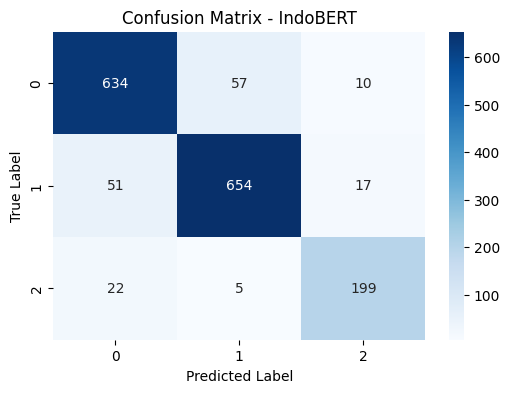

In [ ]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_indobert, y_pred_indobert = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_indobert.extend(preds)
    y_true_indobert.extend(labels)

print("\nClassification Report:")
print(classification_report(y_true_indobert, y_pred_indobert, target_names=unique_labels))

evaluate_metrics(y_true_indobert, y_pred_indobert)
plot_confusion_matrix(y_true_indobert, y_pred_indobert, title=f"Confusion Matrix - {model_name}")

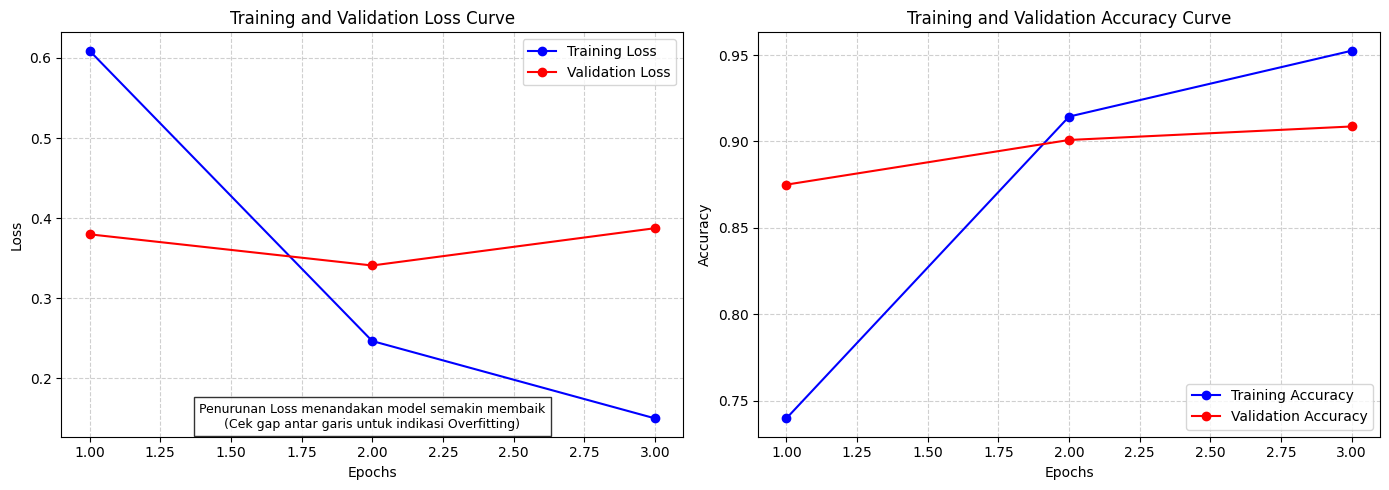

In [ ]:
import matplotlib.pyplot as plt

# Karena ada Early Stopping, jumlah epoch yang berjalan mungkin kurang dari EPOCHS
# Kita ambil panjang list riwayat loss untuk sumbu X
actual_epochs = len(train_losses_indobert)
epochs_range = range(1, actual_epochs + 1)

# Membuat figure dengan 2 subplot (kiri untuk Loss, kanan untuk Accuracy)
plt.figure(figsize=(14, 5))

# ==========================================
# 1. Grafik Training and Validation Loss
# ==========================================
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_indobert, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range, val_losses_indobert, label='Validation Loss', marker='o', color='red')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
# Anotasi penjelasan singkat di grafik
plt.text(0.5, 0.05, 'Penurunan Loss menandakan model semakin membaik\n(Cek gap antar garis untuk indikasi Overfitting)',
         horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

# ==========================================
# 2. Grafik Training and Validation Accuracy
# ==========================================
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_indobert, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_accuracies_indobert, label='Validation Accuracy', marker='o', color='red')
plt.title('Training and Validation Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Merapikan layout agar tidak tumpang tindih
plt.tight_layout()

# Menampilkan grafik
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# ==========================================
# 1. Siapkan Data
# ==========================================
# Asumsi label asli sama untuk semua pengujian (karena menggunakan dataset validasi yang sama)
y_true = np.array(final_val_labels) # atau test_labels

# Catatan Penting: Karena 'final_val_probs' menyimpan probabilitas seluruh kelas (hasil softmax),
# untuk ROC klasifikasi Biner, kita hanya mengambil probabilitas prediksi kelas Positif (indeks ke-1).
y_probs_model1 = np.array(final_val_probs_indobert)[:, 1]
y_probs_model2 = np.array(final_val_probs_model2)[:, 1]   # Ganti dengan variabel model ke-2
y_probs_model3 = np.array(final_val_probs_model3)[:, 1]   # Ganti dengan variabel model ke-3

# ==========================================
# 2. Hitung FPR, TPR, dan AUC untuk masing-masing model
# ==========================================
# Model 1 (IndoBERT)
fpr1, tpr1, _ = roc_curve(y_true, y_probs_model1)
roc_auc1 = auc(fpr1, tpr1)

# Model 2
fpr2, tpr2, _ = roc_curve(y_true, y_probs_model2)
roc_auc2 = auc(fpr2, tpr2)

# Model 3
fpr3, tpr3, _ = roc_curve(y_true, y_probs_model3)
roc_auc3 = auc(fpr3, tpr3)

# ==========================================
# 3. Visualisasi Kurva ROC
# ==========================================
plt.figure(figsize=(8, 6))

# Plot masing-masing model
plt.plot(fpr1, tpr1, color='blue', lw=2, label=f'IndoBERT (AUC = {roc_auc1:.3f})')
plt.plot(fpr2, tpr2, color='green', lw=2, label=f'Model 2 (AUC = {roc_auc2:.3f})')
plt.plot(fpr3, tpr3, color='red', lw=2, label=f'Model 3 (AUC = {roc_auc3:.3f})')

# Plot garis diagonal (baseline penebakan acak)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

# Pengaturan grafik
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Perbandingan Kurva ROC - 3 Model')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Tampilkan plot
plt.show()

In [ ]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_IndoBERT


## Model IndoRoBERTa

In [ ]:
# ==========================================
# IndoRoBERTa Setup
# ==========================================
model_name = "IndoRoBERTa"
print(f"=== Memulai Training untuk {model_name} ===")

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(model_paths[model_name], num_labels=NUM_LABELS)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoRoBERTa ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cahya/roberta-base-indonesian-522M
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ==========================================
# Training Loop IndoRoBERTa
# ==========================================
# Lists to store metrics for plotting
train_losses_indoroberta = []
val_losses_indoroberta = []
train_accuracies_indoroberta = []
val_accuracies_indoroberta = []

# Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indoroberta = []
final_val_labels_indoroberta = []

# [TAMBAHAN BARU] Inisialisasi Early Stopping for IndoRoBERTa
early_stopping_roberta = EarlyStopping(patience=3, path='best_indoroberta_model.pth')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # Ambil label

        model.zero_grad()
        outputs = model(**batch)

        logits = outputs.logits # Ambil logits untuk perhitungan akurasi
        # Hitung loss menggunakan criterion berbobot yang kita buat
        loss = criterion(logits, labels)
        total_train_loss += loss.item()

        # Hitung akurasi pada saat training
        preds = torch.argmax(logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) #

    train_losses_indoroberta.append(avg_train_loss)
    train_accuracies_indoroberta.append(avg_train_accuracy) #

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            logits = outputs.logits
            # Gunakan criterion yang sama untuk validasi
            loss = criterion(logits, labels)

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # Ambil probabilitas untuk ROC/AUC
        probs = F.softmax(logits, dim=1)
        current_val_probs.extend(probs.cpu().numpy())
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indoroberta.append(avg_val_loss)
    val_accuracies_indoroberta.append(avg_val_accuracy)

    # Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indoroberta = current_val_probs
    final_val_labels_indoroberta = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

    # [TAMBAHAN BARU] CEK EARLY STOPPING DI AKHIR EPOCH
    early_stopping_roberta(avg_val_loss, model)

    if early_stopping_roberta.early_stop:
        print("Early stopping terpicu! Menghentikan training lebih awal untuk mencegah overfitting berlanjut.")
        break # Keluar dari loop training

# ==========================================
# [TAMBAHAN BARU] LOAD MODEL TERBAIK SETELAH TRAINING SELESAI
# ==========================================
print("\nMemuat (loading) kembali bobot model terbaik...")
model.load_state_dict(torch.load('best_indoroberta_model.pth'))
print("Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).")

Epoch 1/3 Validation: 100%|██████████| 104/104 [00:10<00:00, 10.19it/s, loss=0.274]


Epoch 1/3 | Train Loss: 0.7408 | Train Acc: 0.6765 | Val Loss: 0.4614 | Val Acc: 0.8341
Validation loss menurun. Model disimpan!


Epoch 2/3 Validation: 100%|██████████| 104/104 [00:10<00:00, 10.20it/s, loss=0.0247]


Epoch 2/3 | Train Loss: 0.3846 | Train Acc: 0.8604 | Val Loss: 0.3969 | Val Acc: 0.8648
Validation loss menurun. Model disimpan!


Epoch 3/3 Validation: 100%|██████████| 104/104 [00:10<00:00, 10.22it/s, loss=0.00982]


Epoch 3/3 | Train Loss: 0.2734 | Train Acc: 0.9030 | Val Loss: 0.4279 | Val Acc: 0.8762
EarlyStopping counter: 1 out of 3

Memuat (loading) kembali bobot model terbaik...
Selesai! Model sekarang berada pada kondisi terbaiknya (berdasarkan validation loss).



--- Evaluasi Akhir pada Data Test ---
Accuracy  : 0.8599
F1 Score  : 0.8599
Precision : 0.8602
Recall    : 0.8599


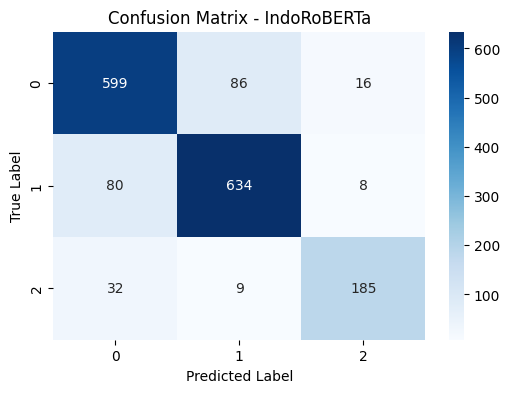


Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85       701
     Neutral       0.87      0.88      0.87       722
    Positive       0.89      0.82      0.85       226

    accuracy                           0.86      1649
   macro avg       0.87      0.85      0.86      1649
weighted avg       0.86      0.86      0.86      1649



In [ ]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_roberta, y_pred_roberta = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_roberta.extend(preds)
    y_true_roberta.extend(labels)

evaluate_metrics(y_true_roberta, y_pred_roberta)
plot_confusion_matrix(y_true_roberta, y_pred_roberta, title=f"Confusion Matrix - {model_name}")
print("\nClassification Report:")
print(classification_report(y_true_roberta, y_pred_roberta, target_names=unique_labels))

In [ ]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_IndoRoBERTa


## Model IndoElectra

In [ ]:
# ==========================================
# IndoELECTRA Setup
# ==========================================
model_name = "IndoELECTRA"
print(f"=== Memulai Training untuk {model_name} ===")

# Buat DataLoader
train_dataset = SentimentDataset(tokenized_inputs[model_name]['train'], train_labels_encoded)
val_dataset = SentimentDataset(tokenized_inputs[model_name]['val'], val_labels_encoded)
test_dataset = SentimentDataset(tokenized_inputs[model_name]['test'], test_labels_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inisialisasi Model
model = AutoModelForSequenceClassification.from_pretrained(model_paths[model_name], num_labels=NUM_LABELS)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

=== Memulai Training untuk IndoELECTRA ===


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: mesolitica/electra-base-discriminator-bahasa-cased
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [ ]:
# ==========================================
# Training Loop
# ==========================================
# Lists to store metrics for plotting
train_losses_indoelectra = []
val_losses_indoelectra = []
val_accuracies_indoelectra = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        model.zero_grad()
        outputs = model(**batch)

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses_indoelectra.append(avg_train_loss) # Store train loss

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        labels = batch['labels'].flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)
    val_losses_indoelectra.append(avg_val_loss)       # Store val loss
    val_accuracies_indoelectra.append(avg_val_accuracy) # Store val accuracy

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")

Epoch 1/3 Training:   1%|▏         | 7/481 [00:02<02:56,  2.69it/s, loss=0.946]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 76, in get_conversion_pr_reference
    raise OSError(
OSError: Could not create safetensors conversion PR. The re

Epoch 1/3 | Train Loss: 0.6579 | Val Loss: 0.5811 | Val Acc: 0.7806


Epoch 2/3 Validation: 100%|██████████| 104/104 [00:13<00:00,  7.43it/s, loss=0.0689]


Epoch 2/3 | Train Loss: 0.5061 | Val Loss: 0.5144 | Val Acc: 0.8005


Epoch 3/3 Validation: 100%|██████████| 104/104 [00:14<00:00,  7.40it/s, loss=0.045]

Epoch 3/3 | Train Loss: 0.4263 | Val Loss: 0.5124 | Val Acc: 0.8053


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

# ==========================================
# Training Loop IndoELECTRA
# ==========================================
# Lists to store metrics for plotting
train_losses_indoelectra = []
val_losses_indoelectra = []
train_accuracies_indoelectra = [] # [TAMBAHAN] Untuk akurasi training
val_accuracies_indoelectra = []

# [TAMBAHAN] Lists untuk menyimpan probabilitas epoch terakhir demi kurva ROC
final_val_probs_indoelectra = []
final_val_labels_indoelectra = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0 # [TAMBAHAN]

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    for batch in train_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten() # [TAMBAHAN] Ambil label

        model.zero_grad()
        outputs = model(**batch)

        loss = outputs.loss
        logits = outputs.logits # [TAMBAHAN] Ambil logits untuk perhitungan akurasi
        total_train_loss += loss.item()

        # [TAMBAHAN] Hitung akurasi pada saat training
        preds = torch.argmax(logits, dim=1).flatten()
        total_train_accuracy += (preds == labels).cpu().numpy().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_accuracy = total_train_accuracy / len(train_loader) # [TAMBAHAN]

    train_losses_indoelectra.append(avg_train_loss)
    train_accuracies_indoelectra.append(avg_train_accuracy) # [TAMBAHAN]

    # Validation
    model.eval()
    total_val_loss, total_val_accuracy = 0, 0

    # [TAMBAHAN] List sementara untuk ROC di epoch saat ini
    current_val_probs = []
    current_val_labels = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Validation")
    for batch in val_loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch['labels'].flatten()

        with torch.no_grad():
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

        total_val_loss += loss.item()
        preds = torch.argmax(logits, dim=1).flatten()
        total_val_accuracy += (preds == labels).cpu().numpy().mean()

        # [TAMBAHAN] Ambil probabilitas untuk kelas positif (indeks 1) untuk ROC/AUC
        probs = F.softmax(logits, dim=1)[:, 1]
        current_val_probs.extend(probs.cpu().numpy())
        current_val_labels.extend(labels.cpu().numpy())

        val_loop.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_accuracy = total_val_accuracy / len(val_loader)

    val_losses_indoelectra.append(avg_val_loss)
    val_accuracies_indoelectra.append(avg_val_accuracy)

    # [TAMBAHAN] Simpan hasil prediksi validasi hanya dari epoch terakhir untuk digambar di ROC
    final_val_probs_indoelectra = current_val_probs
    final_val_labels_indoelectra = current_val_labels

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_accuracy:.4f}")


--- Evaluasi Akhir pada Data Test ---
Accuracy  : 0.8035
F1 Score  : 0.7871
Precision : 0.7870
Recall    : 0.8035


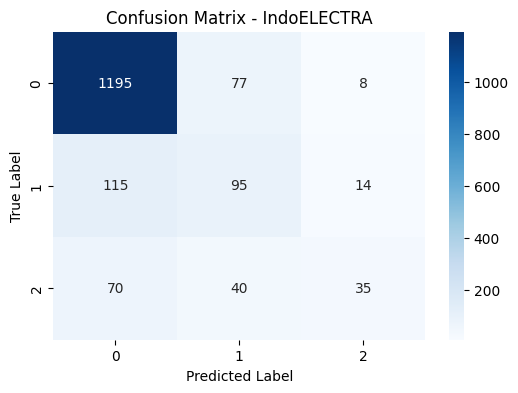


Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.93      0.90      1280
     Neutral       0.45      0.42      0.44       224
    Positive       0.61      0.24      0.35       145

    accuracy                           0.80      1649
   macro avg       0.64      0.53      0.56      1649
weighted avg       0.79      0.80      0.79      1649



In [ ]:
# ==========================================
# Testing & Evaluasi Akhir
# ==========================================
print("\n--- Evaluasi Akhir pada Data Test ---")
model.eval()
y_true_electra, y_pred_electra = [], []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        logits = outputs.logits

    preds = torch.argmax(logits, dim=1).flatten().cpu().numpy()
    labels = batch['labels'].flatten().cpu().numpy()

    y_pred_electra.extend(preds)
    y_true_electra.extend(labels)

evaluate_metrics(y_true_electra, y_pred_electra)
plot_confusion_matrix(y_true_electra, y_pred_electra, title=f"Confusion Matrix - {model_name}")
print("\nClassification Report:")
print(classification_report(y_true_electra, y_pred_electra, target_names=unique_labels))

In [ ]:
# ==========================================
# Simpan Model
# ==========================================
save_path = f"/content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_{model_name}"
model.save_pretrained(save_path)
tokenizers[model_name].save_pretrained(save_path)
print(f"Model dan Tokenizer disimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer disimpan di: /content/drive/MyDrive/Kuliah/Semester 6/Jurnal/Model/saved_model_IndoELECTRA


# Evaluasi Training

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Function to plot training and validation metrics
def plot_training_metrics(model_name, train_losses, val_losses, val_accuracies, epochs):
    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(14, 6))

    # Plot Loss (Training vs Validation Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_losses, label='Validation Loss', marker='x')
    plt.title(f'{model_name} Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy (Validation Accuracy, also shows Learning Curve/Generalization Gap)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o', color='green')
    plt.title(f'{model_name} Validation Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# --- Plotting for IndoBERT ---
if 'train_losses_indobert' in globals() and 'val_losses_indobert' in globals() and 'val_accuracies_indobert' in globals():
    print("Generating training plots for IndoBERT...")
    plot_training_metrics("IndoBERT", train_losses_indobert, val_losses_indobert, val_accuracies_indobert, EPOCHS)
else:
    print("IndoBERT training metrics not found. Please re-run the IndoBERT training cells (including the 'Training Loop' cell) to collect the data.")

# --- Plotting for IndoRoBERTa ---
if 'train_losses_indoroberta' in globals() and 'val_losses_indoroberta' in globals() and 'val_accuracies_indoroberta' in globals():
    print("\nGenerating training plots for IndoRoBERTa...")
    plot_training_metrics("IndoRoBERTa", train_losses_indoroberta, val_losses_indoroberta, val_accuracies_indoroberta, EPOCHS)
else:
    print("IndoRoBERTa training metrics not found. Please re-run the IndoRoBERTa training cells (including the 'Training Loop' cell) to collect the data.")

# --- Plotting for IndoELECTRA ---
if 'train_losses_indoelectra' in globals() and 'val_losses_indoelectra' in globals() and 'val_accuracies_indoelectra' in globals():
    print("\nGenerating training plots for IndoELECTRA...")
    plot_training_metrics("IndoELECTRA", train_losses_indoelectra, val_losses_indoelectra, val_accuracies_indoelectra, EPOCHS)
else:
    print("IndoELECTRA training metrics not found. Please re-run the IndoELECTRA training cells (including the 'Training Loop' cell) to collect the data.")

print("\nRegarding ROC Curve / AUC:")
print("To generate ROC Curve / AUC, the model's prediction probabilities (logits or softmax outputs) for the test set need to be collected during the evaluation phase.")
print("Currently, only the predicted class labels are stored. If you'd like to include ROC Curve / AUC, the testing loops for each model would need to be modified to store these probabilities.")

IndoBERT training metrics not found. Please re-run the IndoBERT training cells (including the 'Training Loop' cell) to collect the data.
IndoRoBERTa training metrics not found. Please re-run the IndoRoBERTa training cells (including the 'Training Loop' cell) to collect the data.
IndoELECTRA training metrics not found. Please re-run the IndoELECTRA training cells (including the 'Training Loop' cell) to collect the data.

Regarding ROC Curve / AUC:
To generate ROC Curve / AUC, the model's prediction probabilities (logits or softmax outputs) for the test set need to be collected during the evaluation phase.
Currently, only the predicted class labels are stored. If you'd like to include ROC Curve / AUC, the testing loops for each model would need to be modified to store these probabilities.
